<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D0%9D%D0%A1_%D0%B8_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №5. Архитектуры CNN и Transfer Learning.ipynb**

## **Задание 1. Использование предобученной модели**

### **1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from keras.models import Sequential, Model, load_model
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, TensorBoard
from keras.utils import to_categorical, load_img, img_to_array
from keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0
from keras.applications.vgg16 import preprocess_input as vgg16_preprocess, decode_predictions as vgg16_decode
from keras.applications.resnet50 import preprocess_input as resnet_preprocess, decode_predictions as resnet_decode
from keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess, decode_predictions as mobilenet_decode
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive
import seaborn as sns
import requests
from io import BytesIO
from PIL import Image

In [2]:
base_model = VGG16(weights='imagenet', include_top=True)

print(f'Модель загружена. Входной размер: {base_model.input_shape}')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Модель загружена. Входной размер: (None, 224, 224, 3)


### **1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images**

In [8]:
image_urls = [
    'https://avatars.mds.yandex.net/i?id=03618f2002a64873cd305f57a6dbb4941e7aae1a-9243215-images-thumbs&n=13',
    'https://i.pinimg.com/736x/4d/d8/19/4dd81917ea08357f3f9d9e720782c5e3.jpg',
    'https://avatars.mds.yandex.net/i?id=35f59663311edc1d78cd01a53ade978be1d53317-13620566-images-thumbs&n=13',
    'https://avatars.mds.yandex.net/i?id=301ee3089f84fc7f5d8ce1d51b160f530e75961f-5877100-images-thumbs&n=13',
    'https://i.pinimg.com/originals/95/e5/76/95e576473bf9e0d337a903df214b56ce.jpg'
]

images = []
image_classes = ['cat', 'cat', 'dog', 'elephant', 'lion']

print('Загрузка изображений...')
for i, url in enumerate(image_urls):
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))
        img = img.convert('RGB')
        img = img.resize((224, 224))
        images.append(img)
        print(f'Изображение {i+1}: загружено ({image_classes[i]})')
    except Exception as e:
        print(f'Изображение {i+1}: ошибка - {e}')
        images.append(None)

print(f'Всего загружено: {len([i for i in images if i is not None])} изображений')

Загрузка изображений...
Изображение 1: загружено (cat)
Изображение 2: загружено (cat)
Изображение 3: загружено (dog)
Изображение 4: загружено (elephant)
Изображение 5: загружено (lion)
Всего загружено: 5 изображений


### **1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).**

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [9]:
def preprocess_images(images_list, model_type='vgg16'):
    import copy

    images_copy = copy.deepcopy(images_list)

    processed_images = []

    for img in images_copy:
        if img is not None:
            img_array = img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)

            if model_type == 'vgg16':
                img_array = vgg16_preprocess(img_array)
            elif model_type == 'resnet':
                img_array = resnet_preprocess(img_array)
            elif model_type == 'mobilenet':
                img_array = mobilenet_preprocess(img_array)

            processed_images.append(img_array)

    if len(processed_images) > 0:
        return np.vstack(processed_images)
    else:
        return np.array([])

processed_images = preprocess_images(images, model_type='vgg16')
print(f'Размер предобработанных данных: {processed_images.shape}')

Размер предобработанных данных: (5, 224, 224, 3)


### **1.5. Выведите изображения и соответствующие им классы (как в примере из теории)**

In [10]:
predictions = base_model.predict(processed_images, verbose=0)
decoded_predictions = vgg16_decode(predictions, top=3)

print('Результаты предсказания:')
for i, preds in enumerate(decoded_predictions):
    print(f'\nИзображение {i+1} ({image_classes[i]}):')
    for j, (imagenet_id, label, prob) in enumerate(preds):
        print(f'  {j+1}. {label}: {prob*100:.2f}%')

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Результаты предсказания:

Изображение 1 (cat):
  1. tabby: 53.47%
  2. tiger_cat: 26.53%
  3. Egyptian_cat: 13.13%

Изображение 2 (cat):
  1. tabby: 39.51%
  2. tiger_cat: 23.84%
  3. Egyptian_cat: 22.13%

Изображение 3 (dog):
  1. German_shepherd: 99.56%
  2. kelpie: 0.15%
  3. otterhound: 0.09%

Изображение 4 (elephant):
  1. tusker: 33.21%
  2. cowboy_boot: 27.39%
  3. African_elephant: 9.81%

Изображение 5 (lion):
  1. lion: 94.93%
  2. baboon: 2.87%
  3. hyena: 0.57%


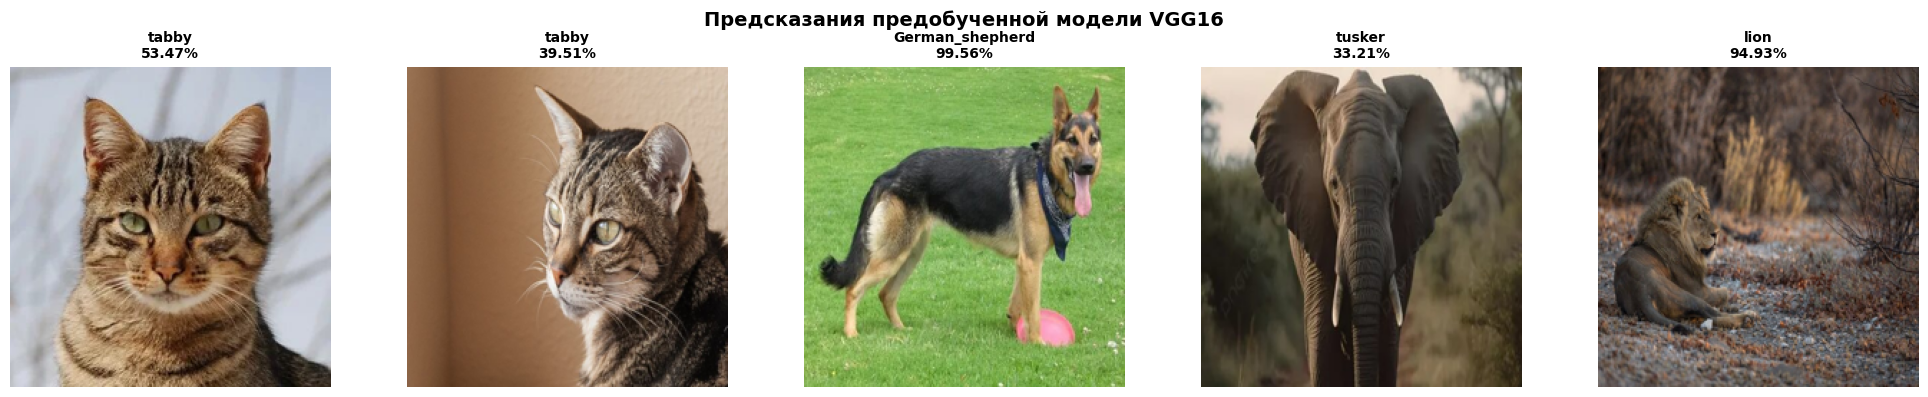

In [11]:
plt.figure(figsize=(20, 4))

for i, img in enumerate(images):
    if img is not None:
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)

        top_pred = decoded_predictions[i][0]
        plt.title(f'{top_pred[1]}\n{top_pred[2]*100:.2f}%', fontsize=10, fontweight='bold')
        plt.axis('off')

plt.suptitle('Предсказания предобученной модели VGG16', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Задание 2. Использование обученной модели для работы со своим датасетом**

### **2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
import tensorflow as tf
help(tf.keras.applications)

Help on package keras.applications in keras:

NAME
    keras.applications - DO NOT EDIT.

DESCRIPTION
    This file was autogenerated. Do not edit it by hand,
    since your modifications would be overwritten.

PACKAGE CONTENTS
    convnext (package)
    densenet (package)
    efficientnet (package)
    efficientnet_v2 (package)
    imagenet_utils (package)
    inception_resnet_v2 (package)
    inception_v3 (package)
    mobilenet (package)
    mobilenet_v2 (package)
    mobilenet_v3 (package)
    nasnet (package)
    resnet (package)
    resnet50 (package)
    resnet_v2 (package)
    vgg16 (package)
    vgg19 (package)
    xception (package)

FILE
    /usr/local/lib/python3.12/dist-packages/keras/applications/__init__.py




In [12]:
base_model_transfer = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Замораживание базовой модели
for layer in base_model_transfer.layers:
    layer.trainable = False

print(f'Базовая модель: VGG16')
print(f'Входной размер: {base_model_transfer.input_shape}')
print(f'Количество слоев: {len(base_model_transfer.layers)}')
print(f'Количество обучаемых слоев: {sum(1 for l in base_model_transfer.layers if l.trainable)}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Базовая модель: VGG16
Входной размер: (None, 64, 64, 3)
Количество слоев: 19
Количество обучаемых слоев: 0


### **2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку**

In [13]:

drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/animals'

def load_animals_dataset_transfer(base_path):
    train_path = os.path.join(base_path, 'train')
    val_path = os.path.join(base_path, 'val')

    class_folders = [f for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))]
    class_folders = sorted(class_folders)
    class_names = class_folders

    print(f'Найдено классов: {len(class_names)}')
    print(f'Классы: {class_names}')

    train_images = []
    train_labels = []
    val_images = []
    val_labels = []

    img_size = (64, 64)
    img_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']

    print('\nЗагрузка training данных...')
    for label, class_folder in enumerate(class_folders):
        class_train_path = os.path.join(train_path, class_folder)

        if not os.path.exists(class_train_path):
            continue

        for f in os.listdir(class_train_path):
            if any(f.lower().endswith(ext) for ext in img_extensions):
                try:
                    img = load_img(os.path.join(class_train_path, f), target_size=img_size)
                    img_array = img_to_array(img) / 255.0
                    train_images.append(img_array)
                    train_labels.append(label)
                except:
                    pass

    print('\nЗагрузка validation данных...')
    for label, class_folder in enumerate(class_folders):
        class_val_path = os.path.join(val_path, class_folder)

        if not os.path.exists(class_val_path):
            continue

        for f in os.listdir(class_val_path):
            if any(f.lower().endswith(ext) for ext in img_extensions):
                try:
                    img = load_img(os.path.join(class_val_path, f), target_size=img_size)
                    img_array = img_to_array(img) / 255.0
                    val_images.append(img_array)
                    val_labels.append(label)
                except:
                    pass

    X_train = np.array(train_images)
    y_train = np.array(train_labels)
    X_val = np.array(val_images)
    y_val = np.array(val_labels)

    print(f'\nTrain: {len(X_train)} изображений')
    print(f'Val: {len(X_val)} изображений')

    return X_train, y_train, X_val, y_val, class_names

X_train_tl, y_train_tl, X_val_tl, y_val_tl, class_names_tl = load_animals_dataset_transfer(DATASET_PATH)

num_classes_tl = len(class_names_tl)
y_train_tl_cat = to_categorical(y_train_tl, num_classes_tl)
y_val_tl_cat = to_categorical(y_val_tl, num_classes_tl)

Mounted at /content/drive
Найдено классов: 5
Классы: ['cat', 'dog', 'elephant', 'horse', 'lion']

Загрузка training данных...

Загрузка validation данных...

Train: 13474 изображений
Val: 1497 изображений


### **2.3. Обучение своей модели на основе предобученной модели** "*название модели, выбранной в п.2.1.*"

In [14]:
def create_transfer_model(base_model, num_classes):
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_transfer = create_transfer_model(base_model_transfer, num_classes_tl)

model_transfer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,881,093 (56.77 MB)

 Trainable params: 165,637 (647.02 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

In [15]:
# Обучение модели с заморозкой базовых слоев
os.makedirs('models/transfer_learning', exist_ok=True)
os.makedirs('logs/transfer_learning', exist_ok=True)

callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/transfer_learning/best_model_frozen.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/transfer_learning/training_history_frozen.csv', append=False),
    TensorBoard(log_dir='logs/transfer_learning/frozen', histogram_freq=1)
]

print('Обучение модели (замороженные слои)...')
history_frozen = model_transfer.fit(
    X_train_tl, y_train_tl_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_tl, y_val_tl_cat),
    callbacks=callbacks_tl,
    verbose=1
)

# Оценка
val_loss_frozen, val_acc_frozen = model_transfer.evaluate(X_val_tl, y_val_tl_cat, verbose=0)
print(f'Frozen Model - Val Accuracy: {val_acc_frozen:.4f} ({val_acc_frozen*100:.2f}%)')

Обучение модели (замороженные слои)...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5328 - loss: 1.3537
Epoch 1: val_accuracy improved from None to 0.75752, saving model to models/transfer_learning/best_model_frozen.h5



Epoch 1: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.6155 - loss: 1.0550 - val_accuracy: 0.7575 - val_loss: 0.5906 - learning_rate: 0.0010
Epoch 2/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7000 - loss: 0.7668
Epoch 2: val_accuracy improved from 0.75752 to 0.78891, saving model to models/transfer_learning/best_model_frozen.h5



Epoch 2: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.7051 - loss: 0.7586 - val_accuracy: 0.7889 - val_loss: 0.5478 - learning_rate: 0.0010
Epoch 3/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7273 - loss: 0.6838
Epoch 3: val_accuracy improved from 0.78891 to 0.79492, saving model to models/transfer_learning/best_model_frozen.h5



Epoch 3: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.7339 - loss: 0.6719 - val_accuracy: 0.7949 - val_loss: 0.5348 - learning_rate: 0.0010
Epoch 4/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7484 - loss: 0.6439
Epoch 4: val_accuracy did not improve from 0.79492
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7477 - loss: 0.6453 - val_accuracy: 0.7769 - val_loss: 0.5443 - learning_rate: 0.0010
Epoch 5/50
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7570 - loss: 0.6166
Epoch 5: val_accuracy improved from 0.79492 to 0.80160, saving model to models/transfer_learning/best_model_frozen.h5



Epoch 5: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.7576 - loss: 0.6218 - val_accuracy: 0.8016 - val_loss: 0.5112 - learning_rate: 0.0010
Epoch 6/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7633 - loss: 0.6000
Epoch 6: val_accuracy improved from 0.80160 to 0.80227, saving model to models/transfer_learning/best_model_frozen.h5



Epoch 6: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7635 - loss: 0.6040 - val_accuracy: 0.8023 - val_loss: 0.5102 - learning_rate: 0.0010
Epoch 7/50
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7677 - loss: 0.5895
Epoch 7: val_accuracy improved from 0.80227 to 0.80628, saving model to models/transfer_learning/best_model_frozen.h5



Epoch 7: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.7684 - loss: 0.5952 - val_accuracy: 0.8063 - val_loss: 0.5013 - learning_rate: 0.0010
Epoch 8/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7742 - loss: 0.5722
Epoch 8: val_accuracy did not improve from 0.80628
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7693 - loss: 0.5865 - val_accuracy: 0.7989 - val_loss: 0.5024 - learning_rate: 0.0010
Epoch 9/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7799 - loss: 0.5681
Epoch 9: val_accuracy did not improve from 0.80628
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7766 - loss: 0.5729 - val_accuracy: 0.7923 - val_loss: 0.5058 - learning_rate: 0.0010
Epoch 10/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7808 - loss: 0.5607
Epoch 10: val_accuracy did not improve from 0.80628
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.7771 - loss: 0.56


Epoch 13: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.7906 - loss: 0.5484 - val_accuracy: 0.8103 - val_loss: 0.4929 - learning_rate: 0.0010
Epoch 14/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7872 - loss: 0.5447
Epoch 14: val_accuracy did not improve from 0.81029
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7846 - loss: 0.5556 - val_accuracy: 0.8083 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 15/50
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7988 - loss: 0.5238
Epoch 15: val_accuracy did not improve from 0.81029
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.7915 - loss: 0.5384 - val_accuracy: 0.8036 - val_loss: 0.4915 - learning_rate: 0.0010
Epoch 16/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7897 - loss: 0.5382
Epoch 16: val_accuracy did not improve from 0.81029
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7925 - loss:


Epoch 21: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7988 - loss: 0.5247 - val_accuracy: 0.8110 - val_loss: 0.4915 - learning_rate: 0.0010
Epoch 22/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7952 - loss: 0.5317
Epoch 22: val_accuracy did not improve from 0.81096
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7972 - loss: 0.5210 - val_accuracy: 0.8096 - val_loss: 0.4937 - learning_rate: 0.0010
Epoch 23/50
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7991 - loss: 0.5288
Epoch 23: val_accuracy improved from 0.81096 to 0.81296, saving model to models/transfer_learning/best_model_frozen.h5



Epoch 23: finished saving model to models/transfer_learning/best_model_frozen.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8007 - loss: 0.5245 - val_accuracy: 0.8130 - val_loss: 0.4740 - learning_rate: 0.0010
Epoch 24/50
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7992 - loss: 0.5239
Epoch 24: val_accuracy did not improve from 0.81296
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.7966 - loss: 0.5285 - val_accuracy: 0.7862 - val_loss: 0.5175 - learning_rate: 0.0010
Epoch 25/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8021 - loss: 0.5114
Epoch 25: val_accuracy did not improve from 0.81296
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8020 - loss: 0.5146 - val_accuracy: 0.8056 - val_loss: 0.4830 - learning_rate: 0.0010
Epoch 26/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8072 - loss: 0.4974
Epoch 26: val_accuracy did not improve from 0.81296
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8028 - loss:

In [16]:
# Разморозка части слоев для дообучения
base_model_transfer.trainable = True

for layer in base_model_transfer.layers[:-4]:
    layer.trainable = False

print(f'Обучаемых слоев после разморозки: {sum(1 for l in model_transfer.layers if l.trainable)}')

model_transfer.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tl_finetune = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/transfer_learning/best_model_finetuned.h5',
                    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/transfer_learning/training_history_finetuned.csv', append=False),
    TensorBoard(log_dir='logs/transfer_learning/finetuned', histogram_freq=1)
]

print('Дообучение модели (размороженные слои)...')
history_finetuned = model_transfer.fit(
    X_train_tl, y_train_tl_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_tl, y_val_tl_cat),
    callbacks=callbacks_tl_finetune,
    verbose=1
)

val_loss_finetuned, val_acc_finetuned = model_transfer.evaluate(X_val_tl, y_val_tl_cat, verbose=0)
print(f'Finetuned Model - Val Accuracy: {val_acc_finetuned:.4f} ({val_acc_finetuned*100:.2f}%)')

Обучаемых слоев после разморозки: 9
Дообучение модели (размороженные слои)...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8101 - loss: 0.4978
Epoch 1: val_accuracy improved from None to 0.81430, saving model to models/transfer_learning/best_model_finetuned.h5



Epoch 1: finished saving model to models/transfer_learning/best_model_finetuned.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8090 - loss: 0.4998 - val_accuracy: 0.8143 - val_loss: 0.4801 - learning_rate: 1.0000e-04
Epoch 2/50
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8165 - loss: 0.4756
Epoch 2: val_accuracy did not improve from 0.81430
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8137 - loss: 0.4840 - val_accuracy: 0.8110 - val_loss: 0.4802 - learning_rate: 1.0000e-04
Epoch 3/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8115 - loss: 0.4825
Epoch 3: val_accuracy improved from 0.81430 to 0.81697, saving model to models/transfer_learning/best_model_finetuned.h5



Epoch 3: finished saving model to models/transfer_learning/best_model_finetuned.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8137 - loss: 0.4761 - val_accuracy: 0.8170 - val_loss: 0.4760 - learning_rate: 1.0000e-04
Epoch 4/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8148 - loss: 0.4761
Epoch 4: val_accuracy improved from 0.81697 to 0.81830, saving model to models/transfer_learning/best_model_finetuned.h5



Epoch 4: finished saving model to models/transfer_learning/best_model_finetuned.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8184 - loss: 0.4737 - val_accuracy: 0.8183 - val_loss: 0.4715 - learning_rate: 1.0000e-04
Epoch 5/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8202 - loss: 0.4572
Epoch 5: val_accuracy improved from 0.81830 to 0.81897, saving model to models/transfer_learning/best_model_finetuned.h5



Epoch 5: finished saving model to models/transfer_learning/best_model_finetuned.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8182 - loss: 0.4686 - val_accuracy: 0.8190 - val_loss: 0.4763 - learning_rate: 1.0000e-04
Epoch 6/50
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8188 - loss: 0.4631
Epoch 6: val_accuracy did not improve from 0.81897
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8198 - loss: 0.4691 - val_accuracy: 0.8156 - val_loss: 0.4774 - learning_rate: 1.0000e-04
Epoch 7/50
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8187 - loss: 0.4661
Epoch 7: val_accuracy did not improve from 0.81897
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8191 - loss: 0.4646 - val_accuracy: 0.8123 - val_loss: 0.4780 - learning_rate: 1.0000e-04
Epoch 8/50
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8221 - loss: 0.4606
Epoch 8: val_accuracy did not improve from 0.81897
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.8222

### **2.4. Визуализация процесса обучения модели**

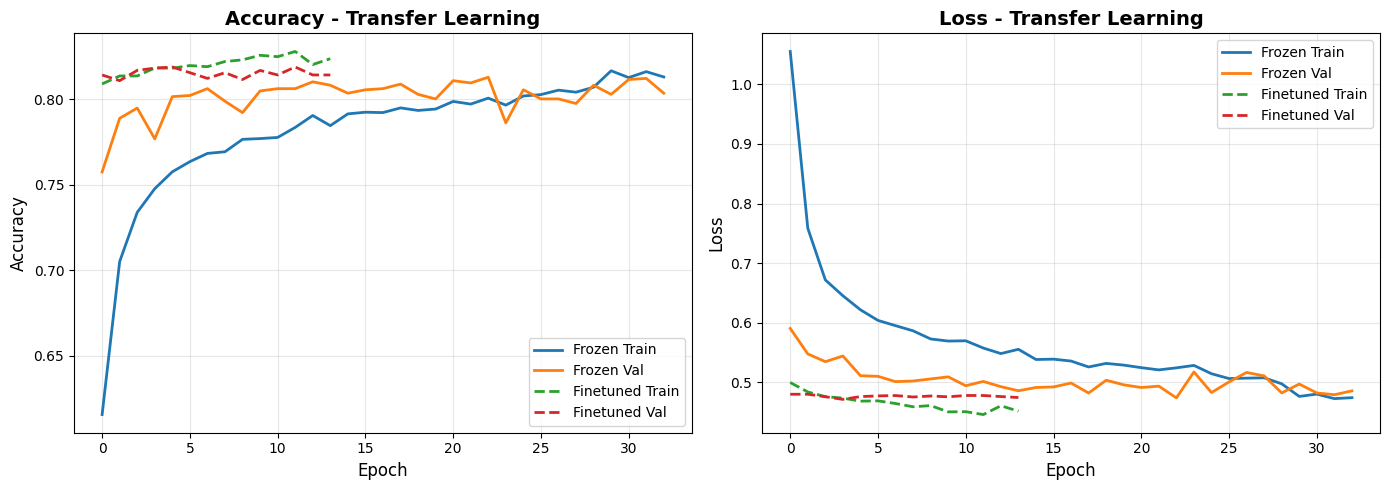

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_frozen.history['accuracy'], label='Frozen Train', linewidth=2)
plt.plot(history_frozen.history['val_accuracy'], label='Frozen Val', linewidth=2)
plt.plot(history_finetuned.history['accuracy'], label='Finetuned Train', linewidth=2, linestyle='--')
plt.plot(history_finetuned.history['val_accuracy'], label='Finetuned Val', linewidth=2, linestyle='--')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy - Transfer Learning', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_frozen.history['loss'], label='Frozen Train', linewidth=2)
plt.plot(history_frozen.history['val_loss'], label='Frozen Val', linewidth=2)
plt.plot(history_finetuned.history['loss'], label='Finetuned Train', linewidth=2, linestyle='--')
plt.plot(history_finetuned.history['val_loss'], label='Finetuned Val', linewidth=2, linestyle='--')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss - Transfer Learning', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **2.5. Подготовьте набор проверочных данных (examples)**

In [18]:
test_indices = np.random.choice(len(X_val_tl), 10, replace=False)
test_images = X_val_tl[test_indices]
test_labels = y_val_tl[test_indices]

print('Проверочные изображения:')
for i, idx in enumerate(test_indices):
    print(f'{i+1}. Класс: {class_names_tl[test_labels[i]]}')

Проверочные изображения:
1. Класс: cat
2. Класс: cat
3. Класс: lion
4. Класс: dog
5. Класс: lion
6. Класс: cat
7. Класс: dog
8. Класс: cat
9. Класс: lion
10. Класс: cat


### **2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow) или люое другое решение.**



Если выбрали Gradio, то в качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [20]:
import ipywidgets as widgets
from IPython.display import display, Image as IPImage
import io

print('Создание интерактивного интерфейса...')

def classify_image(upload):
    if not upload:
        print('Изображение не загружено')
        return

    for name, file_info in upload.items():
        content = file_info['content']

        img = Image.open(io.BytesIO(content))
        img_resized = img.resize((64, 64))

        img_array = img_to_array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model_transfer.predict(img_array, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = np.max(prediction[0]) * 100

        print(f'Предсказанный класс: {class_names_tl[predicted_class]}')
        print(f'Уверенность: {confidence:.2f}%')

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f'{class_names_tl[predicted_class]}\n{confidence:.2f}%', fontsize=12, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Выберите изображение'
)

output = widgets.interactive_output(classify_image, {'upload': uploader})

display(widgets.VBox([
    widgets.HTML('<h3>Классификация животных</h3>'),
    widgets.HTML('<p>Загрузите изображение животного для классификации</p>'),
    uploader,
    output
]))

Создание интерактивного интерфейса...


## **Задание 3. Классификация набора пространственных данных EuroSat (для магистров)**

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
# Ваш код

### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
# Ваш код

### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
# Ваш код



### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



In [ ]:
# Ваш код

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------
